In [1]:
import yfinance as yf
import mplfinance as mpf
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

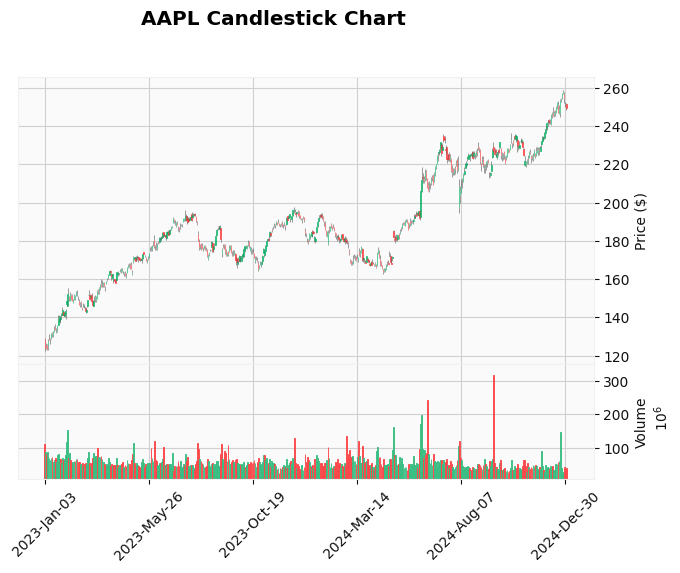

In [54]:
ticker = "AAPL"
ticker_data = yf.Ticker(ticker)
stock_data = stock_data = ticker_data.history(start="2023-01-01",end="2025-01-01",interval='1d')
# Plot the candlestick chart
mpf.plot(stock_data,
         type='candle',
         volume=True,  # Add volume bars
         style='yahoo', # Use a built-in style
         title=f'{ticker} Candlestick Chart',
         ylabel='Price ($)',
         ylabel_lower='Volume'
)

----------------------
1. Download Stock Data
----------------------

In [56]:

df = yf.download(ticker, start="2023-01-01",end="2024-01-01",interval='1d')

# Feature engineering
df["MA5"] = df["Close"].rolling(window=5).mean() # 5 day moving average
df["MA20"] = df["Close"].rolling(window=20).mean() # 20 day moving average
df["Return"] = df["Close"].pct_change()
df["Target"] = df["Close"].shift(-1)

df = df.dropna()

/var/folders/2l/yv87nzw56wx9rzhnzfb_lg5m0000gn/T/ipykernel_79440/3336598296.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start="2023-01-01",end="2024-01-01",interval='1d')
[*********************100%***********************]  1 of 1 completed


----------------------
2. Prepare data
----------------------

In [68]:
features = ["Close", "MA5", "MA20", "Return", "Volume"]
X = df[features]
y = df["Target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, shuffle=False)

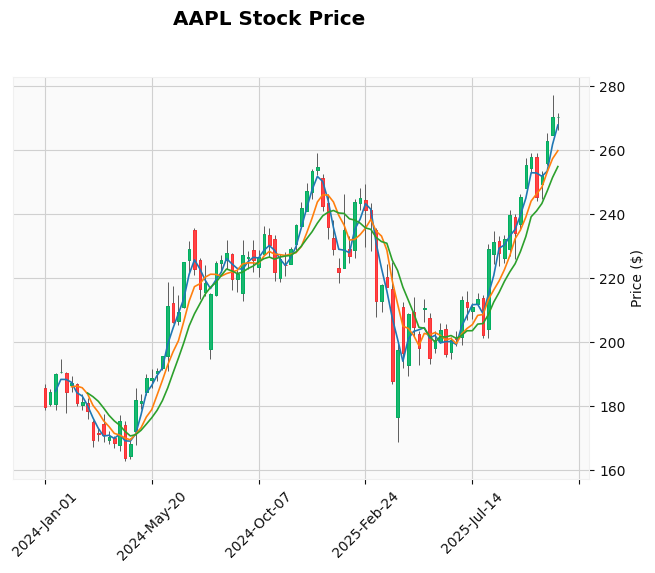

Percent Gain: 48.53


In [49]:
aapl = yf.Ticker(ticker)
stock_data = aapl.history(start="2024-01-01",interval="1wk")
mpf.plot(stock_data, 
         type='candle',        # Chart type: 'candle' for candlestick
         volume=False,          # Overlay volume bars
         show_nontrading=False,# Hide weekends/holidays where no data exists
         mav=(3,6,9),
         title=f"{ticker} Stock Price", 
         ylabel='Price ($)', 
         ylabel_lower='Volume',
         style='yahoo'         # Optional: use a built-in style
)
print(f"Percent Gain: {round(stock_data["Close"].pct_change().sum()*100,2)}")

In [6]:
features = ["Close", "MA5", "MA20", "Return", "Volume"]
X = df[features]
y = df["Target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False
)

----------------------
3. Train model
----------------------

In [69]:
model = RandomForestRegressor(n_estimators=100)
model.fit(X_train, y_train)

preds = model.predict(X_test)
error = mean_absolute_error(y_test, preds)

print(f"Mean Absolute Error: {round(error, 2)}")

Mean Absolute Error: 2.01


----------------------
4. Visualize prediction vs actual
----------------------

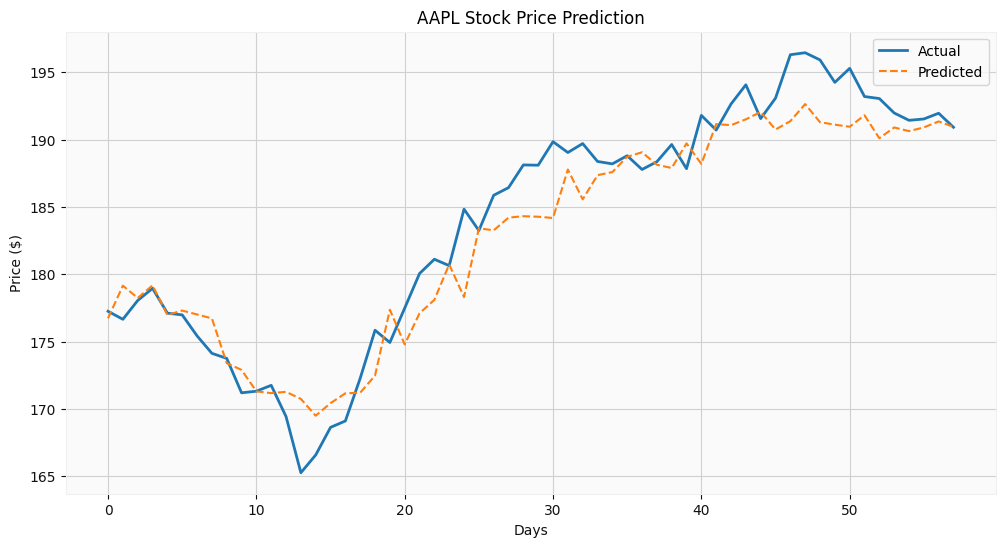

In [70]:
plt.figure(figsize=(12, 6))
plt.plot(y_test.values, label="Actual", linewidth=2)
plt.plot(preds, label="Predicted", linestyle="--")
plt.title(f"{ticker} Stock Price Prediction")
plt.xlabel("Days")
plt.ylabel("Price ($)")
plt.legend()
plt.show()

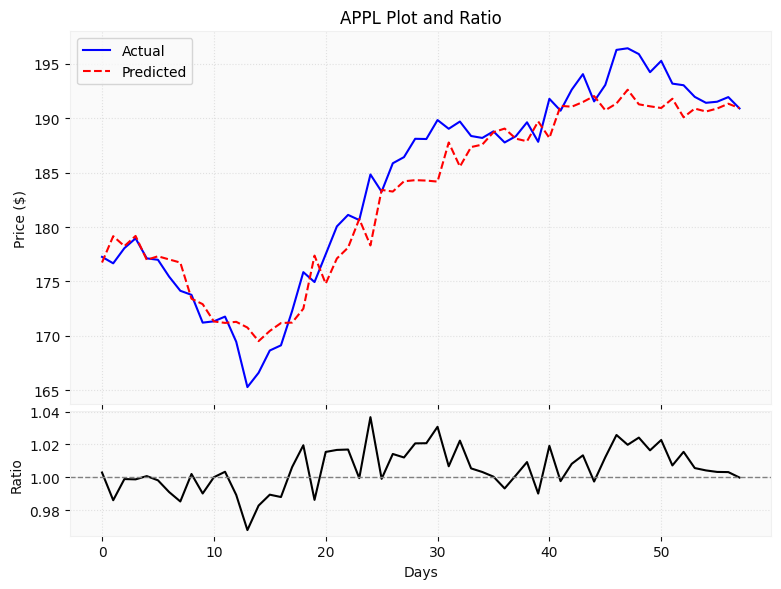

In [71]:
ratio = y_test.values / preds

# 2. Create figure and subplots
# Use gridspec_kw to control the relative height of the subplots
fig, (ax_main, ax_ratio) = plt.subplots(
    nrows=2, 
    ncols=1, 
    sharex=True, 
    gridspec_kw={'height_ratios': [3, 1]}, # Main plot is 3x taller than the ratio plot
    figsize=(8, 6)
)

# 3. Plot the main data
ax_main.plot(y_test.values, label='Actual', color='blue')
ax_main.plot(preds, label='Predicted', color='red', linestyle='--')
ax_main.set_ylabel('Price ($)')
ax_main.set_title('APPL Plot and Ratio')
ax_main.legend()
ax_main.grid(True, linestyle=':', alpha=0.6)

# 4. Plot the ratio
ax_ratio.plot(ratio, color='black', linestyle='-')
ax_ratio.set_xlabel('Days')
ax_ratio.set_ylabel('Ratio')
#ax_ratio.set_ylim(0.9, 1.2) # Set appropriate limits for the ratio plot
ax_ratio.axhline(1.0, color='gray', linestyle='--', linewidth=1) # Add a line at y=1 for reference
ax_ratio.grid(True, linestyle=':', alpha=0.6)

# 5. Adjust layout and display
plt.tight_layout()
# Adjust space between subplots to remove gap
fig.subplots_adjust(hspace=0.03) 
plt.show()